In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv("/content/email.csv")

In [ ]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.tail()

,Category,Message
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name
5572,"{""mode"":""full""",isActive:false}


In [ ]:
df.drop(5572,inplace=True)

In [ ]:
df.tail()

,Category,Message
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [ ]:
df.shape

(5572, 2)

1. Data Cleaning
2. EDA
3. Text Preprocessing
4. Model building
5. Evaluation
6. Improvement
7. Website
8. Deploy


#1. Data Cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
df.rename(columns={'Category':"target",'Message':"text"},inplace=True)
df.sample(5)

,target,text
1905,ham,Wah... Okie okie... Muz make use of e unlimite...
499,ham,"Kate jackson rec center before 7ish, right?"
763,spam,Urgent Ur £500 guaranteed award is still uncla...
109,ham,I know! Grumpy old people. My mom was like you...
4223,ham,Yo you around? A friend of mine's lookin to pi...


In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['target']=encoder.fit_transform(df['target'])
df


,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will ü b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [ ]:
# missing values
df.isnull().sum()

,0
target,0
text,0


In [ ]:
# duplicate values
df.duplicated().sum()

np.int64(415)

In [ ]:
# remove duplicates
df=df.drop_duplicates(keep='first')
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(5157, 2)

#2. EDA

In [ ]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df['target'].value_counts()

,count
target,
0,4516
1,641


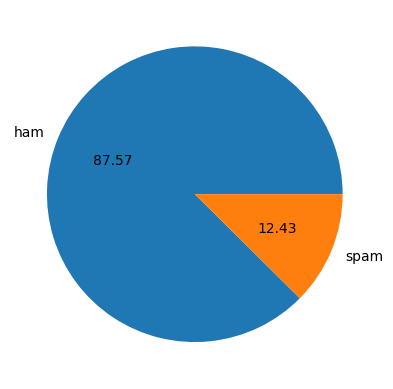

In [ ]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct='%0.2f')
plt.show()

In [ ]:
#data is imbalance
import nltk
!pip install nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
df['num_characters']=df['text'].apply(len)

/tmp/ipykernel_472/399031894.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_characters']=df['text'].apply(len)


In [ ]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [ ]:
#num of words
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

/tmp/ipykernel_472/974858134.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))


In [ ]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [ ]:
df['num_sentence']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

/tmp/ipykernel_472/3985788005.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_sentence']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))


In [ ]:
df.head()

,target,text,num_characters,num_words,num_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [ ]:
df[['num_characters','num_words','num_sentence']].describe()

,num_characters,num_words,num_sentence
count,5157.000000,5157.000000,5157.000000
mean,79.103936,18.560403,1.969750
std,58.382922,13.405970,1.455526
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.000000
75%,118.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


<Axes: xlabel='num_characters', ylabel='Count'>

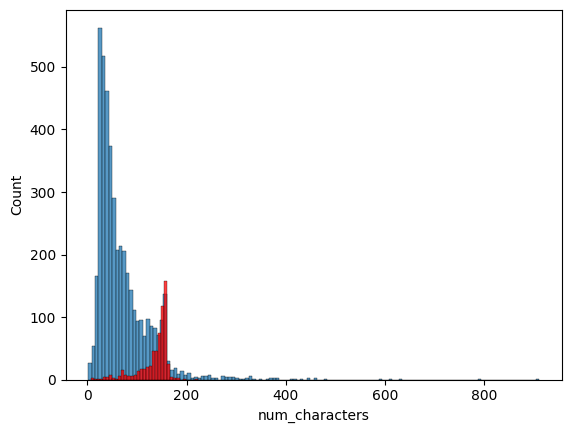

In [ ]:
import seaborn as sns
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

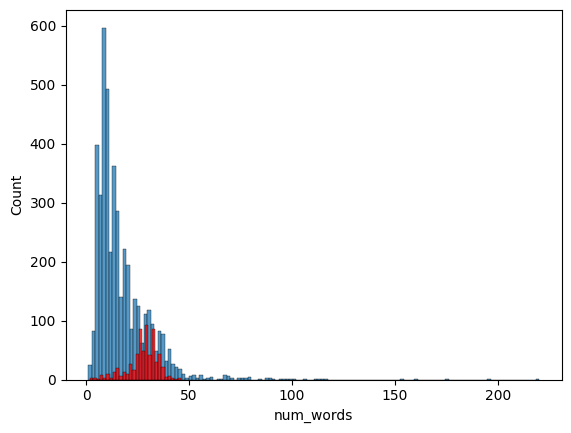

In [ ]:
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')

<Axes: >

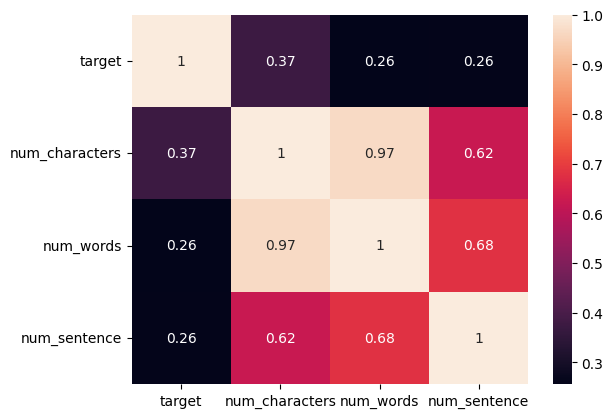

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

#3. Data Preprocessing


*   Lower case
*   Tokenization
*   Remove special characters
*   Remove stop words and punctuation
*   Stemming



In [ ]:
def transform_text(text):
  text=text.lower()
  text=nltk.word_tokenize(text)

  y=[]
  for i in text:
    if i.isalnum():
      y.append(i)
  text=y[:]
  y.clear()

  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)
  text=y[:]
  y.clear()

  for i in text:
    y.append(ps.stem(i))


  return " ".join(y)

In [ ]:
transform_text("Hey I am Learning ML from YT. What about you ? ")

'hey learn ml yt'

In [ ]:
!pip install nltk
nltk.download('stopwords')
nltk.download('PorterStemmer')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Error loading PorterStemmer: Package 'PorterStemmer' not
[nltk_data]     found in index


False

In [ ]:
from nltk.corpus import stopwords
import string

In [ ]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
ps.stem('loved')

'love'

In [ ]:
df['transform_text']=df['text'].apply(transform_text)

/tmp/ipykernel_472/2760768174.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['transform_text']=df['text'].apply(transform_text)


In [ ]:
df.head()

,target,text,num_characters,num_words,num_sentence,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [ ]:
from wordcloud import wordcloud
wc= wordcloud.WordCloud(width=500,height=500,min_font_size=10,background_color='black')

In [ ]:
spam_wc=wc.generate(df[df['target']==1]['transform_text'].str.cat(sep=" "))

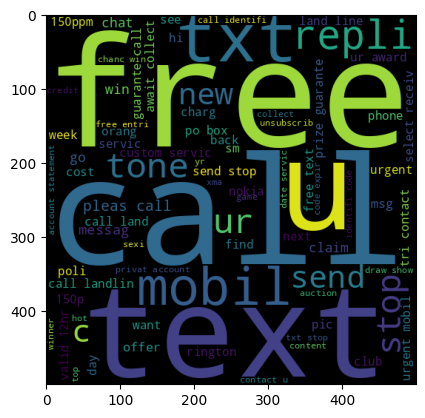

In [ ]:
plt.figsize=(15,6)
plt.imshow(spam_wc)

In [ ]:
ham_wc=wc.generate(df[df['target']==0]['transform_text'].str.cat(sep=" "))

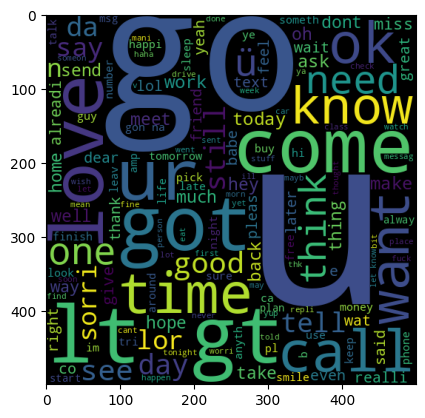

In [ ]:
plt.figsize=(15,6)
plt.imshow(ham_wc)

In [ ]:
spam_corpus=[]
for msg in df[df['target']==1]['transform_text'].tolist():
  for word in msg.split():
    spam_corpus.append(word)

In [ ]:
len(spam_corpus)

9781

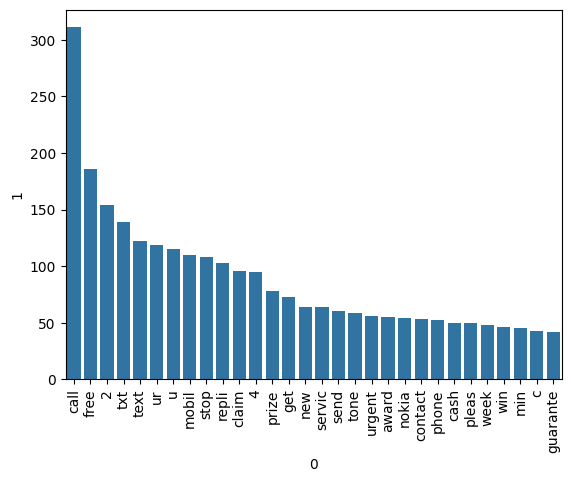

In [ ]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
ham_corpus=[]
for msg in df[df['target']==0]['transform_text'].tolist():
  for word in msg.split():
    ham_corpus.append(word)

In [ ]:
len(ham_corpus)

35940

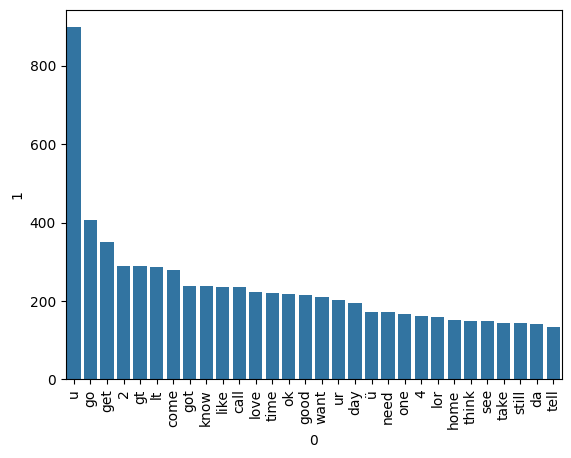

In [ ]:
sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0],y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

#4. Model Building

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
tfidf=TfidfVectorizer(max_features = 3000)

In [ ]:
x=tfidf.fit_transform(df['transform_text']).toarray()

In [ ]:
# from sklearn.preprocessing import MinMaxScaler
# scaler=MinMaxScaler()
# x=scaler.fit_transform(x)

In [ ]:
x.shape

(5157, 3000)

In [ ]:
y=df['target'].values

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [ ]:
from sklearn.naive_bayes import MultinomialNB,GaussianNB,BernoulliNB
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [ ]:
gnb.fit(X_train,y_train)
y_pred1=gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))


0.8672480620155039
[[786 119]
 [ 18 109]]
0.4780701754385965


In [ ]:
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))


0.9718992248062015
[[905   0]
 [ 29  98]]
1.0


In [ ]:
bnb.fit(X_train,y_train)
y_pred3=bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9825581395348837
[[903   2]
 [ 16 111]]
0.9823008849557522


In [ ]:
# tfidf --> mnb(we choose it)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [ ]:
svc=SVC(kernel='sigmoid',gamma=1.0)
knc=KNeighborsClassifier()
mnb=MultinomialNB()
dtc=DecisionTreeClassifier(max_depth=5)
lrc=LogisticRegression(solver='liblinear',penalty='l1')
rfc=RandomForestClassifier(n_estimators=50,random_state=2)
abc=AdaBoostClassifier(n_estimators=50,random_state=2)
bc=BaggingClassifier(n_estimators=50,random_state=2)
etc=ExtraTreesClassifier(n_estimators=50,random_state=2)
gbdt=GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb=XGBClassifier(n_estimators=50,random_state=2)

In [ ]:
clfs={
    'SVC':svc,
    'KN':knc,
    'NB':mnb,
    'DT':dtc,
    'LR':lrc,
    'RF':rfc,
    'AdaBoost':abc,
    'BgC':bc,
    'GBDT':gbdt,
    'xgb':xgb,
    'ETC':etc
}

In [ ]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
  clf.fit(X_train,y_train)
  y_pred=clf.predict(X_test)
  accuracy=accuracy_score(y_test,y_pred)
  precision=precision_score(y_test,y_pred)

  return accuracy,precision

In [ ]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9709302325581395, 0.944954128440367)

In [ ]:
accuracy_results=[]
precision_results=[]
for name,clf in clfs.items():
  current_accuracy,current_precision=train_classifier(clf,X_train,y_train,X_test,y_test)
  print("For ",name)
  print("Accuracy - ",current_accuracy)
  print("Precision - ",current_precision)
  accuracy_results.append(current_accuracy)
  precision_results.append(current_precision)

For  SVC
Accuracy -  0.9777131782945736
Precision -  0.9905660377358491
For  KN
Accuracy -  0.9127906976744186
Precision -  1.0
For  NB
Accuracy -  0.9718992248062015
Precision -  1.0
For  DT
Accuracy -  0.935077519379845
Precision -  0.8125
For  LR
Accuracy -  0.9583333333333334
Precision -  0.9375
For  RF
Accuracy -  0.9718992248062015
Precision -  1.0
For  AdaBoost
Accuracy -  0.9302325581395349
Precision -  0.8666666666666667
For  BgC
Accuracy -  0.9612403100775194
Precision -  0.8918918918918919
For  GBDT
Accuracy -  0.9573643410852714
Precision -  0.9770114942528736
For  xgb
Accuracy -  0.9709302325581395
Precision -  0.9619047619047619
For  ETC
Accuracy -  0.9806201550387597
Precision -  1.0


In [ ]:
performance=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_results,'Precision':precision_results}).sort_values('Precision',ascending=False)

In [ ]:
performance

,Algorithm,Accuracy,Precision
1,KN,0.904070,1.000000
2,NB,0.961240,1.000000
5,RF,0.967054,1.000000
10,ETC,0.973837,1.000000
0,SVC,0.971899,0.980392
8,GBDT,0.953488,0.975904
9,xgb,0.969961,0.970588
4,LR,0.951550,0.923077
7,BgC,0.962209,0.907407
6,AdaBoost,0.930233,0.857143


In [ ]:
# model improve
# 1. change the max_feature parameter of Tfidf
temp_df=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_maxft_3000':accuracy_results,'Precision_maxft_3000':precision_results}).sort_values('Precision_maxft_3000',ascending=False)

In [ ]:
temp_df

,Algorithm,Accuracy_maxft_3000,Precision_maxft_3000
1,KN,0.912791,1.000000
2,NB,0.971899,1.000000
5,RF,0.971899,1.000000
10,ETC,0.980620,1.000000
0,SVC,0.977713,0.990566
8,GBDT,0.957364,0.977011
9,xgb,0.970930,0.961905
4,LR,0.958333,0.937500
7,BgC,0.961240,0.891892
6,AdaBoost,0.930233,0.866667


In [ ]:
performance=performance.merge(temp_df,on='Algorithm')
performance

,Algorithm,Accuracy,Precision,Accuracy_maxft_3000,Precision_maxft_3000
0,KN,0.904070,1.000000,0.912791,1.000000
1,NB,0.961240,1.000000,0.971899,1.000000
2,RF,0.967054,1.000000,0.971899,1.000000
3,ETC,0.973837,1.000000,0.980620,1.000000
4,SVC,0.971899,0.980392,0.977713,0.990566
5,GBDT,0.953488,0.975904,0.957364,0.977011
6,xgb,0.969961,0.970588,0.970930,0.961905
7,LR,0.951550,0.923077,0.958333,0.937500
8,BgC,0.962209,0.907407,0.961240,0.891892
9,AdaBoost,0.930233,0.857143,0.930233,0.866667


In [ ]:
scaler_df=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaler_maxft_3000':accuracy_results,'Precision_scaler_maxft_3000':precision_results}).sort_values('Precision_scaler_maxft_3000',ascending=False)

In [ ]:
scaler_df

,Algorithm,Accuracy_scaler_maxft_3000,Precision_scaler_maxft_3000
1,KN,0.910853,1.000000
10,ETC,0.980620,1.000000
5,RF,0.971899,1.000000
2,NB,0.982558,0.982301
8,GBDT,0.957364,0.977011
4,LR,0.963178,0.968421
9,xgb,0.970930,0.961905
0,SVC,0.970930,0.944954
7,BgC,0.961240,0.891892
6,AdaBoost,0.930233,0.866667


In [ ]:
new_df=performance.merge(scaler_df,on='Algorithm')

In [ ]:
new_df

,Algorithm,Accuracy,Precision,Accuracy_maxft_3000,Precision_maxft_3000,Accuracy_scaler_maxft_3000,Precision_scaler_maxft_3000
0,KN,0.904070,1.000000,0.912791,1.000000,0.910853,1.000000
1,NB,0.961240,1.000000,0.971899,1.000000,0.982558,0.982301
2,RF,0.967054,1.000000,0.971899,1.000000,0.971899,1.000000
3,ETC,0.973837,1.000000,0.980620,1.000000,0.980620,1.000000
4,SVC,0.971899,0.980392,0.977713,0.990566,0.970930,0.944954
5,GBDT,0.953488,0.975904,0.957364,0.977011,0.957364,0.977011
6,xgb,0.969961,0.970588,0.970930,0.961905,0.970930,0.961905
7,LR,0.951550,0.923077,0.958333,0.937500,0.963178,0.968421
8,BgC,0.962209,0.907407,0.961240,0.891892,0.961240,0.891892
9,AdaBoost,0.930233,0.857143,0.930233,0.866667,0.930233,0.866667


In [ ]:
# Voting Classifier
nb = MultinomialNB(alpha=0.1)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

etc = ExtraTreesClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
from sklearn.ensemble import VotingClassifier

In [ ]:
voting = VotingClassifier(
    estimators=[
        ('nb', nb),
        ('rf', rf),
        ('etc', etc)
    ],
    voting='soft'
)

In [ ]:
voting.fit(X_train, y_train)

VotingClassifier(estimators=[('nb', MultinomialNB(alpha=0.1)),
                             ('rf',
                              RandomForestClassifier(n_estimators=300,
                                                     n_jobs=-1,
                                                     random_state=42)),
                             ('etc',
                              ExtraTreesClassifier(n_estimators=300, n_jobs=-1,
                                                   random_state=42))],
                 voting='soft')

In [ ]:
y_pred = voting.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9815891472868217
Precision: 1.0
Recall   : 0.8503937007874016
F1 Score : 0.9191489361702128


In [ ]:
from sklearn.metrics import classification_report

etc.fit(X_train, y_train)

y_pred = etc.predict(X_test)

print(classification_report(
    y_test,
    y_pred,
    target_names=['Ham', 'Spam']
))

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       905
        Spam       0.99      0.79      0.88       127

    accuracy                           0.97      1032
   macro avg       0.98      0.89      0.93      1032
weighted avg       0.97      0.97      0.97      1032



In [ ]:
models = {
    "NB": nb,
    "RF": rf,
    "ETC": etc,
    "Voting": voting
}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("=" * 50)
    print(name)
    print("=" * 50)

    print(classification_report(
        y_test,
        y_pred,
        target_names=["Ham", "Spam"]
    ))

NB
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       905
        Spam       0.96      0.91      0.94       127

    accuracy                           0.98      1032
   macro avg       0.97      0.95      0.96      1032
weighted avg       0.98      0.98      0.98      1032

RF
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       905
        Spam       1.00      0.76      0.86       127

    accuracy                           0.97      1032
   macro avg       0.98      0.88      0.92      1032
weighted avg       0.97      0.97      0.97      1032

ETC
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       905
        Spam       0.99      0.79      0.88       127

    accuracy                           0.97      1032
   macro avg       0.98      0.89      0.93      1032
weighted avg       0.97      0.97      0.97      1032

Voting
  

In [ ]:
import pickle

pickle.dump(nb, open("model.pkl", "wb"))
pickle.dump(tfidf, open("vectorizer.pkl", "wb"))

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [ ]:
from google.colab import files

files.download("model.pkl")
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(nb.n_features_in_)
print(tfidf.get_feature_names_out().shape[0])

6781
3000


In [ ]:
# Train NB using the SAME X_train that was used for NB
nb = MultinomialNB(alpha=0.1)

nb.fit(X_train, y_train)

MultinomialNB(alpha=0.1)

In [ ]:
print("Model features:", nb.n_features_in_)
print("Vectorizer features:", len(tfidf.get_feature_names_out()))

Model features: 3000
Vectorizer features: 3000


In [ ]:
import pickle

pickle.dump(nb, open("model.pkl", "wb"))
pickle.dump(tfidf, open("vectorizer.pkl", "wb"))

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [ ]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'vectorizer.pkl', '.ipynb_checkpoints', 'sample_data']


In [ ]:
print(nb)

MultinomialNB(alpha=0.1)


In [ ]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(nb, f)

print("model.pkl created!")

model.pkl created!


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'model.pkl', 'vectorizer.pkl', '.ipynb_checkpoints', 'sample_data']


In [ ]:
from google.colab import files

files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("NB features:", nb.n_features_in_)
print("TF-IDF features:", len(tfidf.get_feature_names_out()))

NB features: 3000
TF-IDF features: 3000
